In [1]:
using Pkg
Pkg.activate("./../julia-code")

  Activating project at `~/code/compositional/julia-code`


In [2]:
using Meris

In [3]:
using DataFrames, StatsBase, Distributions, LsqFit
using CairoMakie, MakiePublication, LaTeXStrings

In [10]:
# import dataset
arXive_df =  Meris.arXivSampler.collect_arXive();
# bci_df = Meris.BCITreeSampler.load_treedata(; joinquadrats=true, steps=1);
# lego_df = Meris.LegoSampler.parse_themes(; returnthemes=false);

### HYP1: Component's distribution is power-law within a document
If this is true, it may indicate that generation of a single document is done through a Pitman-Yor process.

### HYP2: Heap's law is satisfied for a set of documents of the same type
This is a general law which is found in many complex systems, deviations in some datasets may indicate some "driving" out of "known territory".

### HYP3: The distribution of document sizes is heavy-tailed but with an upper cutoff
Not sure on the relevance of this. Supposition: this distribution introduces some sort of cutoff which yeald the AFD to be a Tweedie distribution for which TL is guaranteed

### HYP4: Taylor's law is satisfied for components within a set of documents
Similarly to Heap's law, TL is found to hold in most complex systems. But is it holding because of HYP1 and/or HYP2? Or is it uncorrelated from them? Also, TL is a very robust pattern and it may indicate that the AFD is a Tweedie distribution, although it is not guaranteed.

### HYP5: AFD (for a single species) follows a distribution in the Pareto family
The idea is that between some lower and upper thresholds, all species follow the same type of distribution

### HYP6: Aggregated AFD is of the same family of the single species AFD
This is true only if the shape parameters of the single species AFD are very similar, if not the same.

In [13]:
df = deepcopy(arXive_df)
df.class .= arXive_df.domain .* "/" .* arXive_df.topic
Meris.DataTools.df_filter!(df; min_samples=20, min_nreads=5000)
first(df, 5)

Row,class,component_id,sample_id,counts,nreads
,String,String,Int64,Int64,Int64
1,physics/ao-ph,atmospheres,2,2,7674
2,physics/ao-ph,doppler,2,4,7674
3,physics/ao-ph,dashed,2,3,7674
4,physics/ao-ph,comparisons,2,1,7674
5,physics/ao-ph,whose,2,1,7674


In [21]:
classes = unique(df.class)
mean_var_dict = Dict()
for class in classes
    mat = Meris.DataTools.get_frequencies(df[df.class .== class, :]; occ=0.95, rescale=false)
    mean_var_dict[class] = Dict()
    mean_var_dict[class]["mean"] = mean(mat, dims=1)
    mean_var_dict[class]["var"] = var(mat, dims=1)
end

In [22]:
mean_var_dict

Dict{Any, Any} with 10 entries:
  "astro-ph/GA"        => Dict{Any, Any}("mean"=>[0.00138706 0.00154173 … 0.000…
  "cond-mat/mtrl-sci"  => Dict{Any, Any}("mean"=>[0.000736908 0.000663572 … 0.0…
  "astro-ph/EP"        => Dict{Any, Any}("mean"=>[0.000664818 0.00152324 … 0.00…
  "physics/ao-ph"      => Dict{Any, Any}("mean"=>[0.00157112 0.00170937 … 0.001…
  "astro-ph/CO"        => Dict{Any, Any}("mean"=>[0.00148696 0.00165674 … 0.000…
  "cond-mat/mes-hall"  => Dict{Any, Any}("mean"=>[0.000807075 0.000540824 … 0.0…
  "q-bio/NC"           => Dict{Any, Any}("mean"=>[0.00484306 0.00218683 … 0.001…
  "cond-mat/quant-gas" => Dict{Any, Any}("mean"=>[0.00206829 0.00126725 … 0.000…
  "astro-ph/SR"        => Dict{Any, Any}("mean"=>[0.00155514 0.00205218 … 0.000…
  "q-bio/BM"           => Dict{Any, Any}("mean"=>[0.000724972 0.000766675 … 0.0…

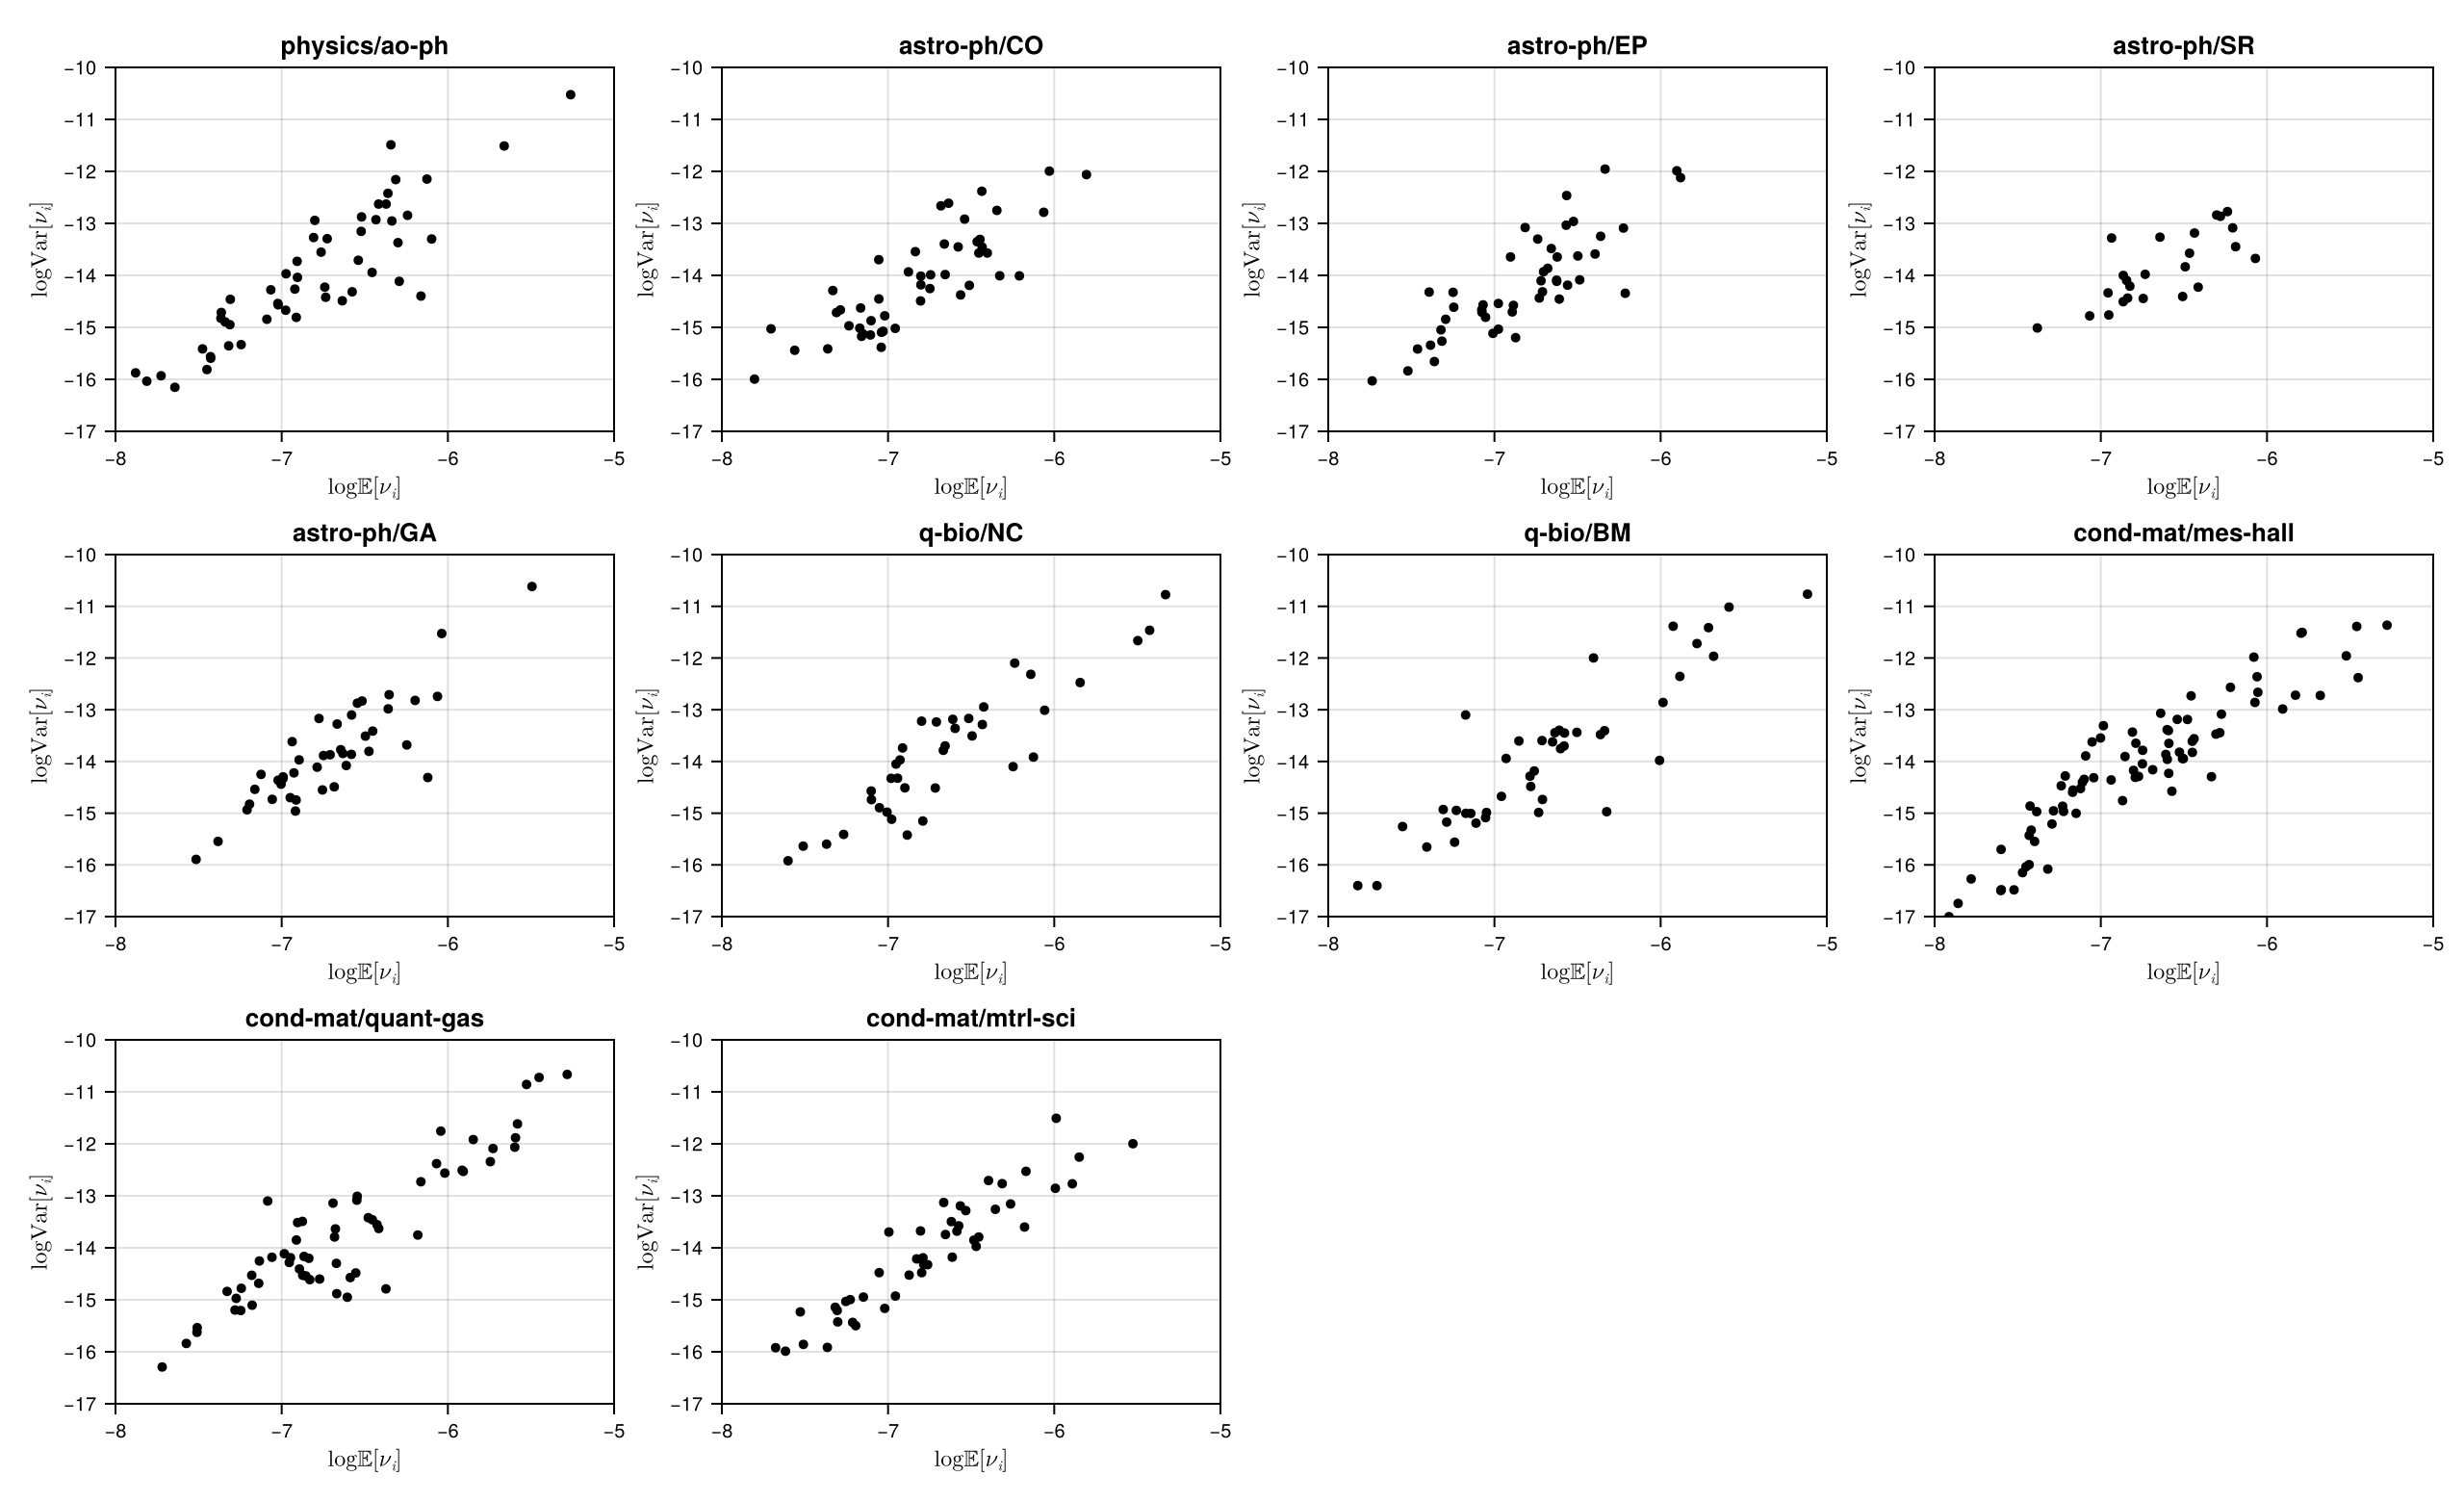

In [34]:
nenv  = length(classes)

ncols = 4
if nenv == 1
    ncols =1
end
nrows = cld(nenv, ncols)            # ceil division
fig   = Figure(size=(320*ncols, 260*nrows))

# Global axis settings
xlims = (-8, -5)
ylims = (-17, -10)

for (i, e) in enumerate(classes)
    row = (i - 1) ÷ ncols + 1
    col = (i - 1) % ncols + 1
    ax = Axis(fig[row, col];
        title = string(e),
        limits = (xlims, ylims),
        xlabel = L"\log\mathbb{E}[\nu_i]",
        ylabel = L"\log\mathrm{Var}[\nu_i]",
        xlabelsize = 12, ylabelsize = 12, titlesize = 13,
        xticklabelsize = 10, yticklabelsize = 10
    )

    # Data for this environment
    x, y = log.(mean_var_dict[e]["mean"]), log.(mean_var_dict[e]["var"])

    # Plots
    scatter!(ax, [x...], [y...]; markersize=7, label="data", color=:black)
    
    # Legend inside each axis
    # axislegend(ax; position=:lt, framevisible=true, labelsize=9, padding=3)
end

# Optional: tighten layout a bit
colgap!(fig.layout, 12)
rowgap!(fig.layout, 10)

fig
